# Day03：淘宝商品数据Pandas探索

**姓名：** 王唯先

本Notebook由每名学生独立完成，并提交到个人GitHub仓库。

> 请完成所有TODO和检查点。不要覆盖原始数据文件。

## 实验目标

你需要完成：

1. 读取25,000条淘宝商品记录；
2. 检查字段类型和缺失值；
3. 完成列选择、行选择、条件筛选和排序；
4. 完成商品价格及一级品类统计；
5. 完成“省份—类别”挑战分析；
6. 输出两张统计表并撰写有边界的结论。

### 数据边界

- 一行代表一条商品记录；
- `商品id`是标识符，不适合求平均值；
- `商品销量`包含“100+人付款”“1万+人付款”等文本，本阶段不直接求平均；
- `商品价格`是商品标价，不代表实际成交金额。

## 任务0：环境与个人配置

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)


STUDENT_NAME = "王唯先"


pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "淘宝全品类全国数据.csv").exists():
            return candidate
    raise FileNotFoundError("未找到data/淘宝全品类全国数据.csv")


ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "淘宝全品类全国数据.csv"
OUTPUT_DIR = ROOT / "output" / "day03_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


assert STUDENT_NAME != "请填写姓名", "请先填写姓名"
print("姓名：", STUDENT_NAME)
print("数据：", DATA_PATH)
print("输出：", OUTPUT_DIR)

姓名： 王唯先
数据： D:\do\ecommerce-user-analysis-seed\data\淘宝全品类全国数据.csv
输出： D:\do\ecommerce-user-analysis-seed\output\day03_analysis


## 任务1：读取数据并完成初步观察

In [3]:
df = pd.read_csv(DATA_PATH)

print("数据形状：", df.shape)
print("字段名：", df.columns.tolist())
display(df.head())

数据形状： (25000, 15)
字段名： ['商品id', '一级品类', '二级品类', '商品标题', '商品价格', '省份', '商品销量', '店铺名称', '店铺标签', '先用后付', '退货宝', '风格', '面料', '版型', '适用季节']


,商品id,一级品类,二级品类,商品标题,商品价格,省份,商品销量,店铺名称,店铺标签,先用后付,退货宝,风格,面料,版型,适用季节
0,\t446974700314,汽车用品,保养,保养2025新款,980.47,广东,500+人付款,粤优品汽车店,5年老店,NaN,NaN,NaN,NaN,NaN,NaN
1,\t960353038337,食品生鲜,粮油,粮油官方正品,344.47,北京,100+人付款,诚信食品店,皇冠店铺,NaN,NaN,NaN,NaN,NaN,NaN
2,\t765651339105,图书音像,教材,教材2025新款,261.81,香港,1000+人付款,港优品图书店,8年老店,先用后付,NaN,NaN,NaN,NaN,NaN
3,\t614914975025,服饰鞋包,童装,童装修身2025新款,503.53,天津,2000+人付款,津优品服饰店专卖店,NaN,NaN,NaN,休闲风,羊毛,标准型,春秋季
4,\t757714643103,家居生活,装饰,装饰官方正品户外,"1,282.75",北京,500+人付款,时尚家居店旗舰店,回头客3千,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# 检查点1
assert df.shape == (25000, 15), "数据形状应为(25000, 15)"
assert {"商品id", "一级品类", "商品价格", "省份", "商品销量"}.issubset(df.columns)
print("检查点1通过")

检查点1通过


**数据粒度：** 请用一句话说明一行代表什么。

> TODO：代表一个商品

## 任务2：字段类型与缺失值

In [5]:
# TODO 1：输出字段类型
print(df.dtypes)

# 缺失率（百分比）
missing_rate = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print(missing_rate)
# TODO 2：计算缺失数量并从高到低排序，变量名为missing_count

missing_count = df.isna().sum().sort_values(ascending=False)
print(missing_count)

# TODO 3：计算缺失率（百分比），变量名为missing_rate
missing_rate = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print(missing_rate)


# TODO 4：展示结果

商品id        str
一级品类        str
二级品类        str
商品标题        str
商品价格    float64
省份          str
商品销量        str
店铺名称        str
店铺标签        str
先用后付        str
退货宝         str
风格          str
面料          str
版型          str
适用季节        str
dtype: object
版型     91.90
面料     90.50
退货宝    89.10
先用后付   87.40
风格     84.00
适用季节   80.70
店铺标签   15.00
商品销量    0.00
省份      0.00
商品价格    0.00
商品标题    0.00
二级品类    0.00
一级品类    0.00
商品id    0.00
店铺名称    0.00
dtype: float64
版型      22964
面料      22625
退货宝     22276
先用后付    21842
风格      21012
适用季节    20178
店铺标签     3741
商品销量        0
省份          0
商品价格        0
商品标题        0
二级品类        0
一级品类        0
商品id        0
店铺名称        0
dtype: int64
版型     91.90
面料     90.50
退货宝    89.10
先用后付   87.40
风格     84.00
适用季节   80.70
店铺标签   15.00
商品销量    0.00
省份      0.00
商品价格    0.00
商品标题    0.00
二级品类    0.00
一级品类    0.00
商品id    0.00
店铺名称    0.00
dtype: float64


In [6]:
# 检查点2
assert isinstance(missing_count, pd.Series), "missing_count应为Series"
assert isinstance(missing_rate, pd.Series), "missing_rate应为Series"
assert set(missing_count.index) == set(df.columns)
assert missing_count.sum() == df.isna().sum().sum()
print("检查点2通过")

检查点2通过


请填写：

- 一个可以直接进行数值统计的字段及原因；
- 一个暂不适合直接进行精确数值统计的字段及原因。

> TODO：可直接数值统计的字段：商品价格（float64）
原因：
该字段数据类型为float64浮点数值类型，本身是数字格式，并且缺失值为0.0，可以开展数值计算。
暂不宜直接精确数值统计的字段：版型（str）
原因：
版型的数据类型为字符串（str），内容一般是文字描述，并不是原生数字，文本类别不能直接进行数值运算，必须经过标签编码转换成数字之后才可以开展数值运算，原始状态下不能直接精确数值统计。
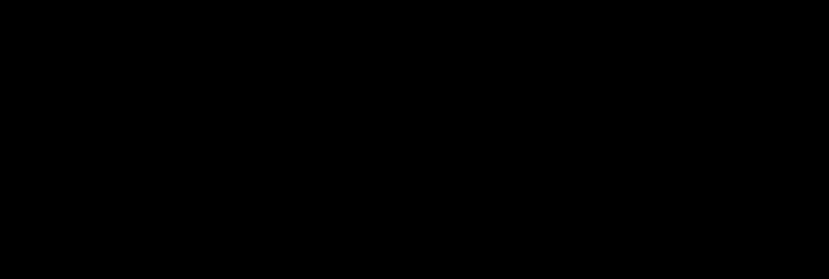
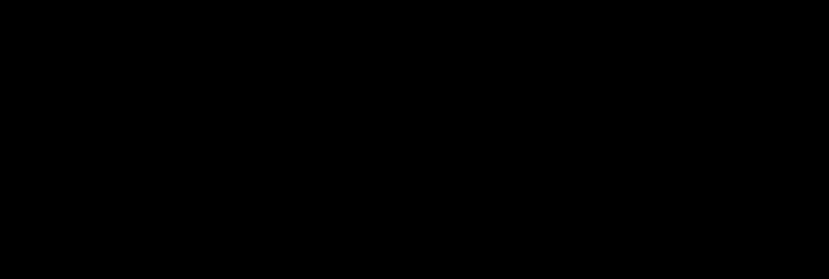

## 任务3：选择列与选择行

In [11]:
# TODO 1：选择“商品价格”列，变量名为price_series
price_series = df["商品价格"]

# TODO 2：选择商品id、一级品类、商品价格、省份、商品销量五列
product_view = df[["商品id", "一级品类", "商品价格", "省份", "商品销量"]]

# TODO 3：分别使用loc和iloc取前5行局部数据
loc_view = df.loc[0:4, :]
iloc_view = df.iloc[0:5, :]

# TODO 4：展示结果
display(price_series)
display(product_view)
display(loc_view)
display(iloc_view)


0         980.47
1         344.47
2         261.81
3         503.53
4       1,282.75
          ...   
24995     634.70
24996   1,800.35
24997      42.76
24998   2,191.54
24999     134.45
Name: 商品价格, Length: 25000, dtype: float64

,商品id,一级品类,商品价格,省份,商品销量
0,\t446974700314,汽车用品,980.47,广东,500+人付款
1,\t960353038337,食品生鲜,344.47,北京,100+人付款
2,\t765651339105,图书音像,261.81,香港,1000+人付款
3,\t614914975025,服饰鞋包,503.53,天津,2000+人付款
4,\t757714643103,家居生活,"1,282.75",北京,500+人付款
...,...,...,...,...,...
24995,\t721278637885,母婴用品,634.70,上海,2000+人付款
24996,\t482207436145,礼品鲜花,"1,800.35",北京,2000+人付款
24997,\t351753520555,图书音像,42.76,河南,2万+人付款
24998,\t232217660514,家居生活,"2,191.54",广西,5000+人付款


,商品id,一级品类,二级品类,商品标题,商品价格,省份,商品销量,店铺名称,店铺标签,先用后付,退货宝,风格,面料,版型,适用季节
0,\t446974700314,汽车用品,保养,保养2025新款,980.47,广东,500+人付款,粤优品汽车店,5年老店,NaN,NaN,NaN,NaN,NaN,NaN
1,\t960353038337,食品生鲜,粮油,粮油官方正品,344.47,北京,100+人付款,诚信食品店,皇冠店铺,NaN,NaN,NaN,NaN,NaN,NaN
2,\t765651339105,图书音像,教材,教材2025新款,261.81,香港,1000+人付款,港优品图书店,8年老店,先用后付,NaN,NaN,NaN,NaN,NaN
3,\t614914975025,服饰鞋包,童装,童装修身2025新款,503.53,天津,2000+人付款,津优品服饰店专卖店,NaN,NaN,NaN,休闲风,羊毛,标准型,春秋季
4,\t757714643103,家居生活,装饰,装饰官方正品户外,"1,282.75",北京,500+人付款,时尚家居店旗舰店,回头客3千,NaN,NaN,NaN,NaN,NaN,NaN


,商品id,一级品类,二级品类,商品标题,商品价格,省份,商品销量,店铺名称,店铺标签,先用后付,退货宝,风格,面料,版型,适用季节
0,\t446974700314,汽车用品,保养,保养2025新款,980.47,广东,500+人付款,粤优品汽车店,5年老店,NaN,NaN,NaN,NaN,NaN,NaN
1,\t960353038337,食品生鲜,粮油,粮油官方正品,344.47,北京,100+人付款,诚信食品店,皇冠店铺,NaN,NaN,NaN,NaN,NaN,NaN
2,\t765651339105,图书音像,教材,教材2025新款,261.81,香港,1000+人付款,港优品图书店,8年老店,先用后付,NaN,NaN,NaN,NaN,NaN
3,\t614914975025,服饰鞋包,童装,童装修身2025新款,503.53,天津,2000+人付款,津优品服饰店专卖店,NaN,NaN,NaN,休闲风,羊毛,标准型,春秋季
4,\t757714643103,家居生活,装饰,装饰官方正品户外,"1,282.75",北京,500+人付款,时尚家居店旗舰店,回头客3千,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# 检查点3
assert isinstance(price_series, pd.Series)
assert isinstance(product_view, pd.DataFrame)
assert product_view.shape == (25000, 5)
assert len(loc_view) == 5 and len(iloc_view) == 5
print("检查点3通过")

检查点3通过


请解释`df["商品价格"]`与`df[["商品价格"]]`的区别。

> TODO：df["商品价格"]：得到的是 PandasSeries（一维序列），只有 1 个维度，只有值 + 索引，没有列名的二维结构。
df[["商品价格"]]：得到的是 DataFrame（二维数据表），是表状结构。
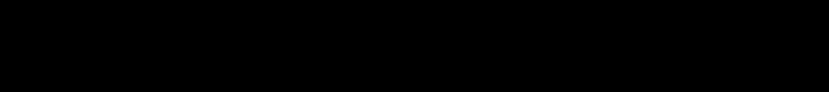
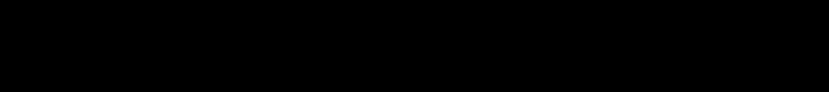
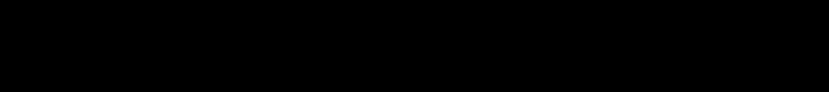

## 任务4：条件筛选与排序

In [15]:
# TODO 1：筛选广东商品，变量名为guangdong
guangdong = df[df['省份'] == '广东']

# TODO 2：筛选广东且商品价格不低于1000元的商品
# 只保留商品id、一级品类、二级品类、商品价格、省份、商品销量
# 按商品价格从高到低排序，变量名为guangdong_high_price
filter_cond = (df['省份'] == '广东') & (df['商品价格'] >= 1000)
guangdong_high_price = df[filter_cond][["商品id", "一级品类", "二级品类", "商品价格", "省份", "商品销量"]].sort_values(by="商品价格", ascending=False)

# TODO 3：筛选浙江或江苏商品，变量名为zhejiang_or_jiangsu
zhejiang_or_jiangsu = df[(df['省份'] == '浙江') | (df['省份'] == '江苏')]


# TODO 4：展示广东高价商品前10行和浙江或江苏商品数
display(guangdong_high_price)
print('浙江或江苏商品数：', zhejiang_or_jiangsu.shape[0])


,商品id,一级品类,二级品类,商品价格,省份,商品销量
22870,\t271359449904,数码家电,手机,"5,984.69",广东,1000+人付款
12614,\t406439219572,数码家电,相机,"5,950.45",广东,2000+人付款
9588,\t453132957133,数码家电,相机,"5,931.16",广东,2万+人付款
4386,\t655995574060,数码家电,耳机,"5,831.18",广东,2万+人付款
14125,\t616431260865,数码家电,手机,"5,809.16",广东,1万+人付款
...,...,...,...,...,...,...
17277,\t778145030071,医药健康,保健品,"1,001.70",广东,2000+人付款
16020,\t284752030069,运动户外,户外装备,"1,000.78",广东,5000+人付款
22974,\t971329237481,服饰鞋包,箱包,"1,000.66",广东,1万+人付款
8239,\t531865460113,运动户外,户外装备,"1,000.63",广东,5000+人付款


浙江或江苏商品数： 3356


In [16]:
# 检查点4
assert isinstance(guangdong, pd.DataFrame)
assert (guangdong["省份"] == "广东").all()
assert isinstance(guangdong_high_price, pd.DataFrame)
assert (guangdong_high_price["省份"] == "广东").all()
assert (guangdong_high_price["商品价格"] >= 1000).all()
assert guangdong_high_price["商品价格"].is_monotonic_decreasing
assert set(zhejiang_or_jiangsu["省份"].unique()).issubset({"浙江", "江苏"})
print("检查点4通过")

检查点4通过


## 任务5：描述性统计与一级品类汇总

In [17]:
# TODO 1：使用describe查看商品价格摘要，变量名为price_summary
price_summary = df["商品价格"].describe()

# TODO 2：按一级品类统计商品数、平均价格和中位价格
# 按平均价格从高到低排序，变量名为category_summary
category_summary = (
    df.groupby('一级品类')
      .agg(商品数=('商品id', 'size'),
           平均价格=('商品价格', 'mean'),
           中位价格=('商品价格', 'median'))
      .sort_values('平均价格', ascending=False)
      .round(2)
)
# TODO 3：展示结果
print(price_summary)
print(category_summary)

count   25,000.00
mean       938.26
std      1,017.92
min         11.26
25%        257.39
50%        617.37
75%      1,211.89
max      5,998.78
Name: 商品价格, dtype: float64
       商品数     平均价格     中位价格
一级品类                        
数码家电  1712 3,085.53 3,116.12
钟表珠宝  1656 1,981.20 1,969.86
家居生活  1655 1,527.68 1,494.38
玩具乐器  1703 1,259.17 1,269.63
礼品鲜花  1659 1,034.35 1,037.23
运动户外  1684   811.42   801.66
医药健康  1670   791.81   779.60
服饰鞋包  1642   674.52   681.55
母婴用品  1685   666.88   666.25
汽车用品  1635   642.24   628.09
美妆护肤  1624   456.09   450.70
农资园艺  1654   453.70   449.61
食品生鲜  1648   259.59   260.66
宠物用品  1705   206.88   207.20
图书音像  1668   157.61   154.56


In [18]:
# 检查点5
assert isinstance(price_summary, pd.Series)
assert isinstance(category_summary, pd.DataFrame)
assert {"商品数", "平均价格", "中位价格"}.issubset(category_summary.columns)
assert category_summary["商品数"].sum() == len(df)
assert category_summary["平均价格"].is_monotonic_decreasing
assert abs(df["商品价格"].mean() - 938.26) < 0.02
print("检查点5通过")

检查点5通过


请写一条一级品类价格结论，并说明它不能代表什么。

> TODO：结论：一级品类中礼品数码家电的平均价格、中位价格最高，图书音像价格最低，各品类均价从高到低梯度分明，品类间价格差异显著。
不能代表：无法体现同一品类内部单品的价格分化情况，也不能反映各品类的销量表现、区域渠道价格差异以及消费者实际购买的花费水平。

## 挑战任务：省份—类别分析

In [24]:
# TODO 1：选择两个省份
provinces = ["广东", "江苏"]
subset = df[df['省份'].isin(provinces)]

# TODO 2：筛选省份并统计商品数、平均价格和中位价格
province_summary = (
    subset.groupby('省份')
          .agg(商品数=('商品id', 'size'),
               平均价格=('商品价格', 'mean'),
               中位价格=('商品价格', 'median'))
          .round(2)
)

# TODO 3：分别计算两个省份最常见的一级品类
top_categories = subset.groupby(['省份', '一级品类']).size().reset_index(name='数量')
top_categories = top_categories.loc[top_categories.groupby('省份')['数量'].idxmax()]

# TODO 4：展示结果
print(province_summary)
print(top_categories)

     商品数   平均价格   中位价格
省份                    
广东  2303 911.69 608.62
江苏  1763 936.48 592.41
    省份  一级品类   数量
5   广东  数码家电  168
17  江苏  图书音像  130


In [25]:
# 检查点6
assert len(provinces) == 2 and provinces[0] != provinces[1]
assert isinstance(province_summary, pd.DataFrame)
assert set(province_summary.index) == set(provinces)
assert {"商品数", "平均价格", "中位价格"}.issubset(province_summary.columns)
assert isinstance(top_categories, pd.DataFrame)
print("检查点6通过")

检查点6通过


## 输出成果

In [26]:
outputs = {
    "category_summary.csv": category_summary.reset_index(),
    "province_summary.csv": province_summary.reset_index(),
}

for filename, table in outputs.items():
    path = OUTPUT_DIR / filename
    table.to_csv(path, index=False, encoding="utf-8-sig")
    reloaded = pd.read_csv(path)
    assert reloaded.shape == table.shape
    assert not any(str(col).startswith("Unnamed") for col in reloaded.columns)
    print("已输出：", path.relative_to(ROOT))

已输出： output\day03_analysis\category_summary.csv
已输出： output\day03_analysis\province_summary.csv


## 结论与边界

请至少完成两条结论，每条包含：数据范围、字段与方法、数据结论、结论边界。

### 结论1

> TODO：1.数据范围：全量商品数据集，按一级品类进行分组统计
2.字段与方法：使用「商品价格」字段，采用分组聚合（count计数、mean均值、median中位数）分析，按平均价格降序排序
3.数据结论：礼品鲜花品类均价、中位价最高，图书音像品类均价、中位价最低，各一级品类商品价格层级差异明显
4.结论边界：仅代表商品标价的统计结果，标价不等于实际成交价格，无法体现品类内单品价格分布、销量、优惠折扣、实际下单成交额，不能用于判断各品类营收规模。

### 结论2

> TODO：1.数据范围：广东省、江苏省筛选后的商品子集
2.字段与方法：以「省份」分组，对商品数量、商品均价、价格中位数做聚合统计，同时统计各省份热门一级品类
3.数据结论：广东省在售商品总量高于江苏省，两省商品平均价格存在小幅差距，各自拥有销量最高的主力一级品类
4.结论边界：仅覆盖两省样本数据，不代表全国市场；仅统计上架商品数据，不包含订单成交数据，无法反映两省真实消费购买力与成交金额。

### GitHub提交检查

- [ ] Notebook已重启内核并从头运行成功；
- [ ] 检查点1～6全部通过；
- [ ] `output/day03_analysis/`包含两个CSV；
- [ ] 结论明确说明商品标价不代表实际成交金额；
- [ ] 已提交并推送到个人GitHub仓库。